# 🎯 Week 5 Sync Session: Data Preprocessing Pipeline
---

### 📋 Session Overview

Welcome to the hands-on sync session! Today we'll build a **complete data preprocessing pipeline** from scratch using a real HR Employee Attrition dataset.

**What You'll Learn:**
- ✅ Assess data quality and identify issues
- ✅ Clean data (missing values, duplicates, outliers, inconsistencies)
- ✅ Perform Exploratory Data Analysis (EDA)
- ✅ Create meaningful visualizations
- ✅ Engineer features (scaling, encoding, creation)
- ✅ Split data correctly to avoid data leakage

**Dataset:** HR Employee Attrition (Dirty Version)
- **Business Problem:** Predict which employees are likely to leave the company
- **Target Variable:** `Attrition` (Yes/No)
- **Note:** This dataset has intentional data quality issues for you to discover and fix!

---

## 📦 Section 0: Setup and Imports

Let's start by importing all the libraries we'll need throughout this session.

In [1]:
# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

# 🎯 Section 1: Know Your Challenge
## From Business Problem to Data

---

### 1.1 Understanding the Business Problem

**Scenario:** You're a data scientist at a large company. HR has noticed high employee turnover and wants to:
1. Understand what factors contribute to employees leaving
2. Build a model to predict which employees are at risk of leaving
3. Take proactive measures to retain valuable employees

**Why This Matters:**
- Replacing an employee costs 50-200% of their annual salary
- Knowledge loss affects team productivity
- High turnover damages company culture

### 1.2 Load the Dataset

In [3]:
# =============================================================================
# LOAD THE DATASET
# =============================================================================

# Load the HR Attrition dataset (dirty version with issues to fix!)
df = pd.read_csv('HR_Employee_Attrition_Dirty.csv')

# First look at the data
print("="*60)
print("📊 DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"\n📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📝 Columns ({len(df.columns)}):")
print(df.columns.tolist())

📊 DATASET LOADED SUCCESSFULLY

📐 Shape: 1524 rows × 37 columns

📝 Columns (37):
['EmployeeNumber', 'TotalWorkingYears', 'PercentSalaryHike', 'NumCompaniesWorked', 'YearsAtCompany', 'MonthlyRate', 'HireDate', 'WorkLifeBalance', 'StandardHours', 'EmployeeCount', 'EducationField', 'BusinessTravel', 'OverTime', 'DistanceFromHome', 'HourlyRate', 'YearsInCurrentRole', 'PerformanceRating', 'DailyRate', 'Attrition', 'Gender', 'Over18', 'JobInvolvement', 'TrainingTimesLastYear', 'YearsSinceLastPromotion', 'ManagerComments', 'JobLevel', 'StockOptionLevel', 'Age', 'JobSatisfaction', 'Department', 'MonthlyIncome', 'EnvironmentSatisfaction', 'MaritalStatus', 'RelationshipSatisfaction', 'YearsWithCurrManager', 'Education', 'JobRole']


In [4]:
# =============================================================================
# FIRST LOOK AT THE DATA
# =============================================================================

# Display first 5 rows
print("\n🔍 First 5 rows of the dataset:")
df.head()


🔍 First 5 rows of the dataset:


,EmployeeNumber,TotalWorkingYears,PercentSalaryHike,NumCompaniesWorked,YearsAtCompany,MonthlyRate,HireDate,WorkLifeBalance,StandardHours,EmployeeCount,EducationField,BusinessTravel,OverTime,DistanceFromHome,HourlyRate,YearsInCurrentRole,PerformanceRating,DailyRate,Attrition,Gender,Over18,JobInvolvement,TrainingTimesLastYear,YearsSinceLastPromotion,ManagerComments,JobLevel,StockOptionLevel,Age,JobSatisfaction,Department,MonthlyIncome,EnvironmentSatisfaction,MaritalStatus,RelationshipSatisfaction,YearsWithCurrManager,Education,JobRole
0,1,16.0,20,5.0,16,7194,2017-07-26,3,80,1,NaN,Non-Travel,no,1,83,2,3,731,no,M,Y,3,2,0,Remote worker,2,3,41.0,2.0,Research & Development,6888.0,2.0,single,4,0,3,Research Scientist
1,2,NaN,15,2.0,0,7805,30/04/2010,2,80,1,Medical,Rarely,NO,2,73,0,3,1401,0,Female,Y,2,3,0,On PIP,2,0,35.0,NaN,Research & Development,9211.0,4.0,married,3,0,4,Research Scientist
2,3,0.0,21,3.0,0,14797,2016-06-12,3,80,1,Medical,travel_rarely,N,24,81,0,3,813,N,MALE,Y,3,2,0,Average,2,1,42.0,3.0,Research and Development,10370.0,4.0,SINGLE,4,0,3,Manufacturing Director
3,4,9.0,18,1.0,9,25106,2013-05-24,2,80,1,Life Sciences,Rarely,NO,24,45,1,4,1169,No,Male,Y,3,1,7,Exceeded expectations,1,0,50.0,4.0,R&D,NaN,2.0,Married,4,3,3,Research Scientist
4,5,15.0,21,2.0,0,18879,2019-09-01,3,80,1,Technical Degree,Travel Rarely,NO,3,45,0,3,1291,YES,F,Y,3,6,0,NaN,4,0,34.0,2.0,R&D,15586.0,4.0,single,3,0,3,Laboratory Technician


In [5]:
# =============================================================================
# DATA TYPES AND BASIC INFO
# =============================================================================

# Check data types and non-null counts
print("\n📋 Dataset Info:")
print("-"*60)
df.info()


📋 Dataset Info:
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1524 entries, 0 to 1523
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeNumber            1524 non-null   int64  
 1   TotalWorkingYears         1441 non-null   float64
 2   PercentSalaryHike         1524 non-null   int64  
 3   NumCompaniesWorked        1462 non-null   float64
 4   YearsAtCompany            1524 non-null   int64  
 5   MonthlyRate               1524 non-null   int64  
 6   HireDate                  1524 non-null   str    
 7   WorkLifeBalance           1524 non-null   int64  
 8   StandardHours             1524 non-null   int64  
 9   EmployeeCount             1524 non-null   int64  
 10  EducationField            1472 non-null   str    
 11  BusinessTravel            1496 non-null   str    
 12  OverTime                  1524 non-null   str    
 

In [6]:
# =============================================================================
# TARGET VARIABLE DISTRIBUTION
# =============================================================================

# Check the distribution of our target variable
# Notice: The values are inconsistent! (Yes, No, Y, N, 1, 0, True, False, etc.)
print("\n🎯 Target Variable Distribution (Attrition) - BEFORE CLEANING:")
print("-"*40)
print(df['Attrition'].value_counts())


🎯 Target Variable Distribution (Attrition) - BEFORE CLEANING:
----------------------------------------
Attrition
False    203
No       197
N        195
NO       195
no       183
0        176
Yes       71
Y         69
yes       64
1         60
True      57
YES       54
Name: count, dtype: int64


### 💡 Key Observation

Notice the **Attrition column has inconsistent values**! We see: 'Yes', 'No', 'Y', 'N', '1', '0', 'True', 'False', 'YES', 'NO', etc.

This is a common data quality issue we need to fix!

---

---

# 🧹 Section 2: Trust Your Data
## From Messy to Clean

---

Before we can analyze or model our data, we need to ensure it's clean and reliable. Let's identify and fix data quality issues.

### 2.1 Data Quality Assessment

In [7]:
# =============================================================================
# CHECK FOR MISSING VALUES
# =============================================================================

# Count missing values in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

# Create a summary dataframe
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

# Show only columns with missing values
print("\n❌ MISSING VALUES SUMMARY")
print("="*50)
missing_with_values = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_with_values)
print(f"\n📊 Total missing values: {df.isnull().sum().sum()}")


❌ MISSING VALUES SUMMARY
                         Missing Count  Missing %
ManagerComments                    198      12.99
MonthlyIncome                      121       7.94
EnvironmentSatisfaction            105       6.89
TotalWorkingYears                   83       5.45
JobSatisfaction                     83       5.45
Age                                 73       4.79
NumCompaniesWorked                  62       4.07
EducationField                      52       3.41
Department                          43       2.82
BusinessTravel                      28       1.84

📊 Total missing values: 848


In [8]:
# =============================================================================
# CHECK FOR DUPLICATE ROWS
# =============================================================================

# Count duplicate rows
n_duplicates = df.duplicated().sum()

print("\n📋 DUPLICATE ROWS CHECK")
print("="*50)
print(f"Number of duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    print("\n⚠️ Duplicate rows found!")
else:
    print("✅ No duplicate rows found.")


📋 DUPLICATE ROWS CHECK
Number of duplicate rows: 0
✅ No duplicate rows found.


In [9]:
# =============================================================================
# CHECK FOR DATA INCONSISTENCIES
# =============================================================================

print("\n🔍 CHECKING DATA CONSISTENCY IN CATEGORICAL COLUMNS")
print("="*60)

# Check unique values in key categorical columns
categorical_cols = ['Attrition', 'Gender', 'OverTime', 'Department', 'MaritalStatus', 'BusinessTravel']

for col in categorical_cols:
    if col in df.columns:
        unique_vals = df[col].unique()
        print(f"\n{col}: {len(unique_vals)} unique values")
        print(f"   Values: {unique_vals}")


🔍 CHECKING DATA CONSISTENCY IN CATEGORICAL COLUMNS

Attrition: 12 unique values
   Values: <StringArray>
['no', '0', 'N', 'No', 'YES', 'False', 'NO', 'True', 'Yes', '1', 'Y', 'yes']
Length: 12, dtype: str

Gender: 10 unique values
   Values: <StringArray>
['M', 'Female', 'MALE', 'Male', 'F', 'male', 'f', 'FEMALE', 'm', 'female']
Length: 10, dtype: str

OverTime: 8 unique values
   Values: <StringArray>
['no', 'NO', 'N', 'No', 'Yes', 'YES', 'Y', 'yes']
Length: 8, dtype: str

Department: 16 unique values
   Values: <StringArray>
[  'Research & Development', 'Research and Development',
                      'R&D',                    'Sales',
     'Research&Development',                     'Sale',
                    'sales',                   'Saless',
   'research & development',                    'SALES',
                        nan,          'Human Resourses',
                     'H.R.',          'Human Resources',
          'human resources',                       'HR']
Length: 16

### 💡 Issues Identified!

We found **major inconsistencies** in categorical columns:

| Column | Issue |
|--------|-------|
| **Attrition** | Mixed formats: Yes/No/Y/N/1/0/True/False/YES/NO |
| **Gender** | Mixed formats: Male/Female/M/F/MALE/FEMALE/male/female |
| **OverTime** | Mixed formats: Yes/No/Y/N/YES/NO |
| **Department** | Typos and variations: R&D/Research & Development/Saless/Sale |
| **MaritalStatus** | Mixed formats: Single/Married/Divorced/S/M/D/Divorsed |
| **BusinessTravel** | Inconsistent: Travel_Rarely/Travel Rarely/Rarely |

---

## 🎯 ACTIVITY 1: Fix the Messy Data (10 minutes)

### Your Tasks:
1. Load the dataset and check its shape ✅ (Done above)
2. Identify columns with missing values ✅ (Done above)
3. Fill missing numerical values with median
4. Remove duplicate rows (if any)
5. Verify: Are there still missing values?

### Helpful Code:
```python
# Check missing
df.isnull().sum()

# Fill with median
df['col'].fillna(df['col'].median())

# Remove duplicates
df.drop_duplicates(inplace=True)
```

---

### 2.2 Data Cleaning

Now let's fix all the issues we identified:
1. Standardize categorical values (Attrition, Gender, OverTime, Department, etc.)
2. Handle missing values
3. Fix invalid/negative values
4. Convert data types appropriately

In [10]:
# =============================================================================
# CREATE A CLEAN COPY OF THE DATA
# =============================================================================

# Always work on a copy to preserve the original
df_clean = df.copy()

print("✅ Created a copy of the dataframe for cleaning")
print(f"   Original shape: {df.shape}")

✅ Created a copy of the dataframe for cleaning
   Original shape: (1524, 37)


In [11]:
# =============================================================================
# STEP 1: STANDARDIZE ATTRITION COLUMN (TARGET VARIABLE)
# =============================================================================

print("\n🧹 STEP 1: STANDARDIZING ATTRITION COLUMN")
print("-"*50)

print(f"Before: {df_clean['Attrition'].unique()}")

# Map all variations to 'Yes' or 'No'
attrition_map = {
    'Yes': 'Yes', 'yes': 'Yes', 'YES': 'Yes', 'Y': 'Yes', 'y': 'Yes',
    '1': 'Yes', 1: 'Yes', 'True': 'Yes', True: 'Yes',
    'No': 'No', 'no': 'No', 'NO': 'No', 'N': 'No', 'n': 'No',
    '0': 'No', 0: 'No', 'False': 'No', False: 'No'
}

df_clean['Attrition'] = df_clean['Attrition'].map(attrition_map)

print(f"After:  {df_clean['Attrition'].unique()}")
print(f"\n✅ Attrition values standardized!")
print(df_clean['Attrition'].value_counts())


🧹 STEP 1: STANDARDIZING ATTRITION COLUMN
--------------------------------------------------
Before: <StringArray>
['no', '0', 'N', 'No', 'YES', 'False', 'NO', 'True', 'Yes', '1', 'Y', 'yes']
Length: 12, dtype: str
After:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str

✅ Attrition values standardized!
Attrition
No     1149
Yes     375
Name: count, dtype: int64


In [12]:
# =============================================================================
# STEP 2: STANDARDIZE GENDER COLUMN
# =============================================================================

print("\n🧹 STEP 2: STANDARDIZING GENDER COLUMN")
print("-"*50)

print(f"Before: {df_clean['Gender'].unique()}")

# Map all variations to 'Male' or 'Female'
gender_map = {
    'Male': 'Male', 'male': 'Male', 'MALE': 'Male', 'M': 'Male', 'm': 'Male',
    'Female': 'Female', 'female': 'Female', 'FEMALE': 'Female', 'F': 'Female', 'f': 'Female'
}

df_clean['Gender'] = df_clean['Gender'].map(gender_map)

print(f"After:  {df_clean['Gender'].unique()}")
print("✅ Gender values standardized!")


🧹 STEP 2: STANDARDIZING GENDER COLUMN
--------------------------------------------------
Before: <StringArray>
['M', 'Female', 'MALE', 'Male', 'F', 'male', 'f', 'FEMALE', 'm', 'female']
Length: 10, dtype: str
After:  <StringArray>
['Male', 'Female']
Length: 2, dtype: str
✅ Gender values standardized!


In [13]:
# =============================================================================
# STEP 3: STANDARDIZE OVERTIME COLUMN
# =============================================================================

print("\n🧹 STEP 3: STANDARDIZING OVERTIME COLUMN")
print("-"*50)

print(f"Before: {df_clean['OverTime'].unique()}")

# Map all variations to 'Yes' or 'No'
overtime_map = {
    'Yes': 'Yes', 'yes': 'Yes', 'YES': 'Yes', 'Y': 'Yes', 'y': 'Yes',
    'No': 'No', 'no': 'No', 'NO': 'No', 'N': 'No', 'n': 'No'
}

df_clean['OverTime'] = df_clean['OverTime'].map(overtime_map)

print(f"After:  {df_clean['OverTime'].unique()}")
print("✅ OverTime values standardized!")


🧹 STEP 3: STANDARDIZING OVERTIME COLUMN
--------------------------------------------------
Before: <StringArray>
['no', 'NO', 'N', 'No', 'Yes', 'YES', 'Y', 'yes']
Length: 8, dtype: str
After:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str
✅ OverTime values standardized!


In [14]:
# =============================================================================
# STEP 4: STANDARDIZE DEPARTMENT COLUMN
# =============================================================================

print("\n🧹 STEP 4: STANDARDIZING DEPARTMENT COLUMN")
print("-"*50)

print(f"Before: {df_clean['Department'].unique()}")

# Map all variations to standard names
department_map = {
    'Research & Development': 'Research & Development',
    'Research and Development': 'Research & Development',
    'Research&Development': 'Research & Development',
    'research & development': 'Research & Development',
    'R&D': 'Research & Development',
    'Sales': 'Sales', 'sales': 'Sales', 'SALES': 'Sales',
    'Sale': 'Sales', 'Saless': 'Sales',
    'Human Resources': 'Human Resources',
    'human resources': 'Human Resources',
    'Human Resourses': 'Human Resources',
    'H.R.': 'Human Resources'
}

df_clean['Department'] = df_clean['Department'].map(department_map)

print(f"After:  {df_clean['Department'].unique()}")
print("✅ Department values standardized!")


🧹 STEP 4: STANDARDIZING DEPARTMENT COLUMN
--------------------------------------------------
Before: <StringArray>
[  'Research & Development', 'Research and Development',
                      'R&D',                    'Sales',
     'Research&Development',                     'Sale',
                    'sales',                   'Saless',
   'research & development',                    'SALES',
                        nan,          'Human Resourses',
                     'H.R.',          'Human Resources',
          'human resources',                       'HR']
Length: 16, dtype: str
After:  <StringArray>
['Research & Development', 'Sales', nan, 'Human Resources']
Length: 4, dtype: str
✅ Department values standardized!


In [15]:
# =============================================================================
# STEP 5: STANDARDIZE MARITAL STATUS COLUMN
# =============================================================================

print("\n🧹 STEP 5: STANDARDIZING MARITAL STATUS COLUMN")
print("-"*50)

print(f"Before: {df_clean['MaritalStatus'].unique()}")

# Map all variations to standard names
marital_map = {
    'Single': 'Single', 'single': 'Single', 'SINGLE': 'Single', 'S': 'Single',
    'Married': 'Married', 'married': 'Married', 'MARRIED': 'Married', 'M': 'Married',
    'Divorced': 'Divorced', 'divorced': 'Divorced', 'DIVORCED': 'Divorced', 'D': 'Divorced',
    'Divorsed': 'Divorced'
}

df_clean['MaritalStatus'] = df_clean['MaritalStatus'].map(marital_map)

print(f"After:  {df_clean['MaritalStatus'].unique()}")
print("✅ MaritalStatus values standardized!")


🧹 STEP 5: STANDARDIZING MARITAL STATUS COLUMN
--------------------------------------------------
Before: <StringArray>
[  'single',  'married',   'SINGLE',  'Married',        'M', 'DIVORCED',
        'S',   'Single', 'divorced', 'Divorsed',        'D',  'MARRIED',
 'Divorced']
Length: 13, dtype: str
After:  <StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str
✅ MaritalStatus values standardized!


In [16]:
# =============================================================================
# STEP 6: STANDARDIZE BUSINESS TRAVEL COLUMN
# =============================================================================

print("\n🧹 STEP 6: STANDARDIZING BUSINESS TRAVEL COLUMN")
print("-"*50)

print(f"Before: {df_clean['BusinessTravel'].unique()}")

# Map all variations to standard names
travel_map = {
    'Non-Travel': 'Non-Travel', 'Non Travel': 'Non-Travel', 'non-travel': 'Non-Travel', 'No Travel': 'Non-Travel',
    'Travel_Rarely': 'Travel_Rarely', 'Travel Rarely': 'Travel_Rarely', 'travel_rarely': 'Travel_Rarely', 'Rarely': 'Travel_Rarely',
    'Travel_Frequently': 'Travel_Frequently', 'Travel Frequently': 'Travel_Frequently', 'travel_frequently': 'Travel_Frequently', 'Frequently': 'Travel_Frequently'
}

df_clean['BusinessTravel'] = df_clean['BusinessTravel'].map(travel_map)

print(f"After:  {df_clean['BusinessTravel'].unique()}")
print("✅ BusinessTravel values standardized!")


🧹 STEP 6: STANDARDIZING BUSINESS TRAVEL COLUMN
--------------------------------------------------
Before: <StringArray>
[       'Non-Travel',            'Rarely',     'travel_rarely',
     'Travel Rarely',        'Non Travel', 'Travel Frequently',
        'Frequently',        'non-travel', 'travel_frequently',
     'Travel_Rarely',         'No Travel',                 nan,
 'Travel_Frequently']
Length: 13, dtype: str
After:  <StringArray>
['Non-Travel', 'Travel_Rarely', 'Travel_Frequently', nan]
Length: 4, dtype: str
✅ BusinessTravel values standardized!


In [17]:
# =============================================================================
# STEP 7: FIX DATA TYPES
# =============================================================================

print("\n🧹 STEP 7: FIXING DATA TYPES")
print("-"*50)

# Convert Age to numeric (it's currently object type)
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
print(f"Age converted to: {df_clean['Age'].dtype}")

# Convert MonthlyIncome to numeric
df_clean['MonthlyIncome'] = pd.to_numeric(df_clean['MonthlyIncome'], errors='coerce')
print(f"MonthlyIncome converted to: {df_clean['MonthlyIncome'].dtype}")

# Convert DistanceFromHome to numeric
df_clean['DistanceFromHome'] = pd.to_numeric(df_clean['DistanceFromHome'], errors='coerce')
print(f"DistanceFromHome converted to: {df_clean['DistanceFromHome'].dtype}")

print("\n✅ Data types fixed!")


🧹 STEP 7: FIXING DATA TYPES
--------------------------------------------------
Age converted to: float64
MonthlyIncome converted to: float64
DistanceFromHome converted to: float64

✅ Data types fixed!


In [18]:
# =============================================================================
# STEP 8: FIX INVALID/NEGATIVE VALUES
# =============================================================================

print("\n🧹 STEP 8: FIXING INVALID VALUES")
print("-"*50)

# Fix negative values in year columns (replace with NaN for imputation)
year_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 
             'YearsWithCurrManager', 'TotalWorkingYears']

for col in year_cols:
    if col in df_clean.columns:
        neg_mask = df_clean[col] < 0
        if neg_mask.sum() > 0:
            print(f"Fixing {neg_mask.sum()} negative values in {col}")
            df_clean.loc[neg_mask, col] = np.nan

print("\n✅ Invalid values marked for imputation!")


🧹 STEP 8: FIXING INVALID VALUES
--------------------------------------------------
Fixing 1 negative values in YearsAtCompany
Fixing 1 negative values in YearsSinceLastPromotion
Fixing 1 negative values in YearsWithCurrManager
Fixing 1 negative values in TotalWorkingYears

✅ Invalid values marked for imputation!


In [19]:
# =============================================================================
# STEP 9: HANDLE MISSING VALUES
# =============================================================================

print("\n🧹 STEP 9: HANDLING MISSING VALUES")
print("-"*50)

# Check current missing values
print("Missing values before imputation:")
missing_now = df_clean.isnull().sum()
print(missing_now[missing_now > 0])

# For numerical columns: use median (robust to outliers)
numerical_cols_to_impute = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked',
                            'JobSatisfaction', 'EnvironmentSatisfaction', 'DistanceFromHome',
                            'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                            'YearsWithCurrManager']

print("\nImputing numerical columns with median:")
for col in numerical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"   {col}: filled with median = {median_value:.2f}")

# For categorical columns: use mode (most frequent)
categorical_cols_to_impute = ['Department', 'BusinessTravel', 'EducationField']

print("\nImputing categorical columns with mode:")
for col in categorical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"   {col}: filled with mode = {mode_value}")

print(f"\n✅ Missing values after imputation: {df_clean[numerical_cols_to_impute + categorical_cols_to_impute].isnull().sum().sum()}")


🧹 STEP 9: HANDLING MISSING VALUES
--------------------------------------------------
Missing values before imputation:
TotalWorkingYears           84
NumCompaniesWorked          62
YearsAtCompany               1
EducationField              52
BusinessTravel              28
DistanceFromHome           132
YearsSinceLastPromotion      1
ManagerComments            198
Age                        217
JobSatisfaction             83
Department                  57
MonthlyIncome              262
EnvironmentSatisfaction    105
YearsWithCurrManager         1
dtype: int64

Imputing numerical columns with median:
   Age: filled with median = 37.00
   MonthlyIncome: filled with median = 8072.00
   TotalWorkingYears: filled with median = 7.00
   NumCompaniesWorked: filled with median = 2.00
   JobSatisfaction: filled with median = 3.00
   EnvironmentSatisfaction: filled with median = 3.00
   DistanceFromHome: filled with median = 5.00
   YearsAtCompany: filled with median = 2.00
   YearsSinceLastProm

In [20]:
# =============================================================================
# STEP 10: DETECT AND HANDLE OUTLIERS (IQR Method)
# =============================================================================

print("\n🧹 STEP 10: DETECTING OUTLIERS (IQR Method)")
print("-"*50)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in key numerical columns
outlier_cols = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'TotalWorkingYears']

for col in outlier_cols:
    if col in df_clean.columns:
        outliers, lower, upper = detect_outliers_iqr(df_clean, col)
        print(f"\n{col}:")
        print(f"   Bounds: [{lower:.2f}, {upper:.2f}]")
        print(f"   Outliers found: {len(outliers)}")


🧹 STEP 10: DETECTING OUTLIERS (IQR Method)
--------------------------------------------------

MonthlyIncome:
   Bounds: [-2201.00, 18751.00]
   Outliers found: 9

Age:
   Bounds: [14.50, 58.50]
   Outliers found: 11

YearsAtCompany:
   Bounds: [-3.50, 8.50]
   Outliers found: 117

TotalWorkingYears:
   Bounds: [-13.50, 30.50]
   Outliers found: 71


In [21]:
# =============================================================================
# DROP UNNECESSARY COLUMNS
# =============================================================================

print("\n🧹 DROPPING UNNECESSARY COLUMNS")
print("-"*50)

# Columns that don't add value for ML
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 
                'HireDate', 'ManagerComments']

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop)

print(f"Dropped columns: {existing_cols_to_drop}")
print(f"\nRemaining columns: {len(df_clean.columns)}")


🧹 DROPPING UNNECESSARY COLUMNS
--------------------------------------------------
Dropped columns: ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'HireDate', 'ManagerComments']

Remaining columns: 31


In [22]:
# =============================================================================
# DATA CLEANING SUMMARY
# =============================================================================

print("\n" + "="*60)
print("📊 DATA CLEANING SUMMARY")
print("="*60)
print(f"\nOriginal dataset:    {len(df)} rows × {len(df.columns)} columns")
print(f"Cleaned dataset:     {len(df_clean)} rows × {len(df_clean.columns)} columns")
print(f"\nMissing values:      {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows:      {df_clean.duplicated().sum()}")
print(f"\n✅ Data is now clean and ready for analysis!")


📊 DATA CLEANING SUMMARY

Original dataset:    1524 rows × 37 columns
Cleaned dataset:     1524 rows × 31 columns

Missing values:      1085
Duplicate rows:      32

✅ Data is now clean and ready for analysis!


---

# 🔍 Section 3: Find the Signal
## From Numbers to Insights (EDA)

---

Now that our data is clean, let's explore it to find patterns and insights.

### 3.1 Descriptive Statistics

In [23]:
# =============================================================================
# DESCRIPTIVE STATISTICS
# =============================================================================

print("\n📊 DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS")
print("="*60)

df_clean.describe().round(2)


📊 DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS


,TotalWorkingYears,PercentSalaryHike,NumCompaniesWorked,YearsAtCompany,MonthlyRate,WorkLifeBalance,DistanceFromHome,HourlyRate,YearsInCurrentRole,PerformanceRating,DailyRate,JobInvolvement,TrainingTimesLastYear,YearsSinceLastPromotion,JobLevel,StockOptionLevel,Age,JobSatisfaction,MonthlyIncome,EnvironmentSatisfaction,RelationshipSatisfaction,YearsWithCurrManager,Education
count,1440.00,1524.00,1462.0,1523.00,1524.00,1524.00,1392.00,1524.00,1524.00,1524.00,1524.00,1524.00,1524.00,1523.00,1524.00,1524.00,1307.00,1441.00,1262.00,1419.00,1524.00,1523.00,1524.00
mean,9.49,17.64,2.0,3.04,14531.88,2.86,7.34,63.78,1.17,3.23,816.28,2.85,2.71,0.87,2.17,0.91,36.86,2.85,8639.19,2.80,2.93,1.16,2.96
std,9.35,4.03,1.4,3.52,7204.60,0.90,7.22,20.17,1.59,2.48,403.74,0.93,1.37,1.26,1.18,1.01,8.66,1.08,3864.39,1.04,1.00,1.51,1.08
min,0.00,11.00,0.0,0.00,2012.00,0.00,1.00,30.00,0.00,3.00,102.00,1.00,-3.00,0.00,1.00,0.00,18.00,1.00,1000.00,1.00,1.00,0.00,1.00
25%,3.00,14.00,1.0,1.00,8445.25,2.00,2.00,46.00,0.00,3.00,473.00,2.00,2.00,0.00,1.00,0.00,31.00,2.00,5656.00,2.00,2.00,0.00,2.00
50%,7.00,18.00,2.0,2.00,14416.00,3.00,5.00,64.00,1.00,3.00,829.00,3.00,3.00,0.00,2.00,1.00,37.00,3.00,8072.00,3.00,3.00,1.00,3.00
75%,14.00,21.00,3.0,4.00,20954.75,4.00,10.00,81.00,2.00,3.00,1167.00,4.00,3.00,1.00,3.00,2.00,42.00,4.00,10894.00,4.00,4.00,2.00,4.00
max,40.00,24.00,9.0,28.00,26998.00,4.00,29.00,99.00,12.00,99.00,1499.00,4.00,6.00,8.00,5.00,3.00,60.00,10.00,29810.00,4.00,4.00,12.00,7.00


In [24]:
# =============================================================================
# ATTRITION RATE BY DIFFERENT SEGMENTS
# =============================================================================

print("\n📊 ATTRITION RATE BY SEGMENT")
print("="*60)

# Convert Attrition to numeric for calculations
df_clean['Attrition_Numeric'] = (df_clean['Attrition'] == 'Yes').astype(int)

# By Department
print("\n🏢 By Department:")
dept_attrition = df_clean.groupby('Department')['Attrition_Numeric'].agg(['mean', 'count'])
dept_attrition.columns = ['Attrition Rate', 'Count']
dept_attrition['Attrition Rate'] = (dept_attrition['Attrition Rate'] * 100).round(1)
print(dept_attrition.sort_values('Attrition Rate', ascending=False))


📊 ATTRITION RATE BY SEGMENT

🏢 By Department:
                        Attrition Rate  Count
Department                                   
Human Resources                   34.0     53
Sales                             26.6    443
Research & Development            23.5    971


In [25]:
# =============================================================================
# ATTRITION BY OVERTIME
# =============================================================================

print("\n⏰ By OverTime:")
ot_attrition = df_clean.groupby('OverTime')['Attrition_Numeric'].agg(['mean', 'count'])
ot_attrition.columns = ['Attrition Rate', 'Count']
ot_attrition['Attrition Rate'] = (ot_attrition['Attrition Rate'] * 100).round(1)
print(ot_attrition)


⏰ By OverTime:
          Attrition Rate  Count
OverTime                       
No                  22.1   1094
Yes                 30.9    430


---

## 🎯 ACTIVITY 2: Discover Patterns (8 minutes)

### Your Task:
Find 3 interesting patterns using groupby, correlation, or descriptive stats.

### Ideas to explore:
- Job roles with highest attrition
- OverTime vs Attrition
- JobSatisfaction by Department

### Share format:
- What did you look at?
- What did you find?
- Why does this matter for prediction?

---

In [26]:
# =============================================================================
# CORRELATION ANALYSIS
# =============================================================================

print("\n📊 CORRELATION WITH ATTRITION")
print("="*60)

# Select numerical columns for correlation
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation with Attrition
correlations = df_clean[numerical_cols].corr()['Attrition_Numeric'].drop('Attrition_Numeric').sort_values(ascending=False)

print("\nTop Positive Correlations with Attrition:")
print(correlations.head(10).round(3))

print("\nTop Negative Correlations with Attrition:")
print(correlations.tail(10).round(3))


📊 CORRELATION WITH ATTRITION

Top Positive Correlations with Attrition:
DistanceFromHome           0.068
MonthlyRate                0.060
EnvironmentSatisfaction    0.044
StockOptionLevel           0.025
Education                  0.020
NumCompaniesWorked         0.019
TotalWorkingYears          0.017
JobInvolvement             0.016
DailyRate                  0.015
JobLevel                   0.012
Name: Attrition_Numeric, dtype: float64

Top Negative Correlations with Attrition:
PerformanceRating         -0.016
PercentSalaryHike         -0.020
YearsSinceLastPromotion   -0.024
TrainingTimesLastYear     -0.028
Age                       -0.035
YearsWithCurrManager      -0.056
WorkLifeBalance           -0.060
YearsInCurrentRole        -0.071
YearsAtCompany            -0.078
JobSatisfaction           -0.108
Name: Attrition_Numeric, dtype: float64


---

# 📊 Section 4: Make It Clear
## From Stats to Visuals

---

Visualizations help us understand patterns and communicate findings effectively.

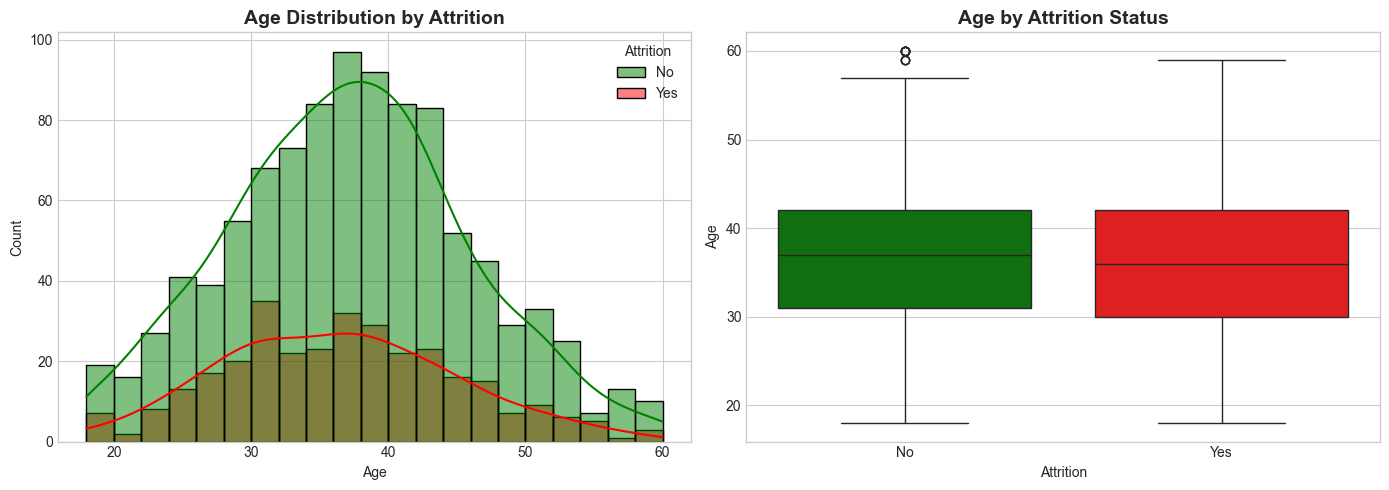

In [27]:
# =============================================================================
# AGE DISTRIBUTION BY ATTRITION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by Attrition
sns.histplot(data=df_clean, x='Age', hue='Attrition', kde=True, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Age Distribution by Attrition', fontsize=14, fontweight='bold')

# Box plot by Attrition
sns.boxplot(data=df_clean, x='Attrition', y='Age', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Age by Attrition Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

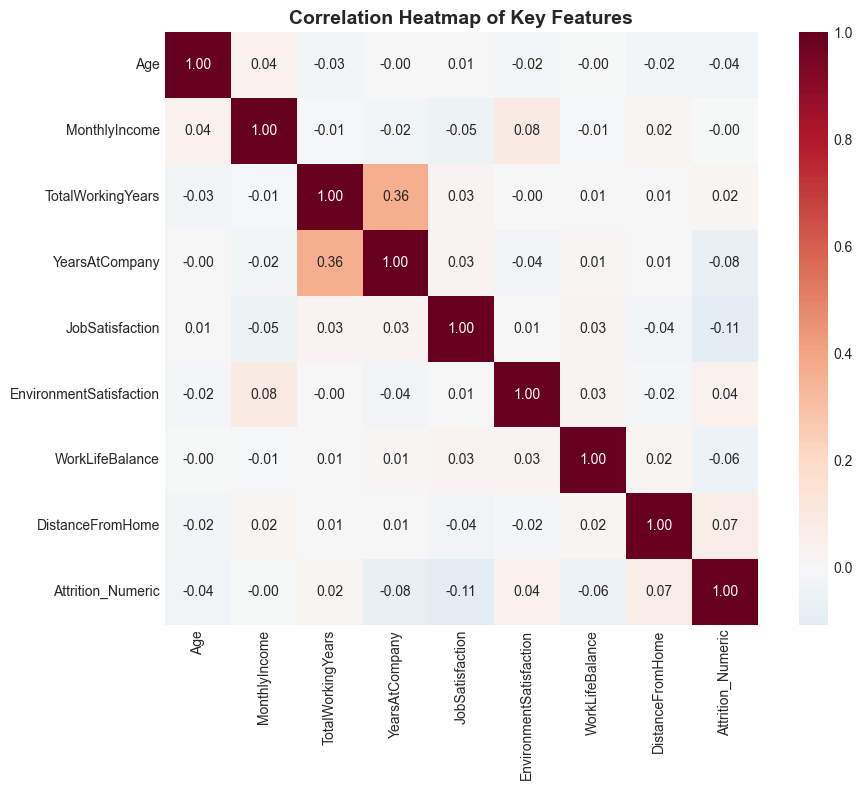

In [28]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

# Select key numerical features for the heatmap
key_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 
                'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 
                'DistanceFromHome', 'Attrition_Numeric']

key_features = [col for col in key_features if col in df_clean.columns]

# Calculate correlation matrix
corr_matrix = df_clean[key_features].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 🎯 ACTIVITY 3: Tell the Story with Charts (10 minutes)

### Create 3 visualizations:
1. **Age distribution by Attrition** (histplot with hue)
2. **Attrition rate by Department** (barplot or countplot)
3. **Correlation heatmap** (top 10 features)

### Checklist:
- ✅ Clear title
- ✅ Labeled axes
- ✅ Legend (if applicable)
- ✅ Business insight

---

---

# ⚙️ Section 5: Shape for Success
## From Raw to Engineered Features

---

Now we'll transform our data to make it suitable for machine learning algorithms.

In [29]:
# =============================================================================
# CREATE A COPY FOR FEATURE ENGINEERING
# =============================================================================

df_features = df_clean.copy()

# Numerical columns that need scaling
scale_cols = ['Age', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate',
              'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 
              'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

scale_cols = [col for col in scale_cols if col in df_features.columns]

print("📊 COLUMNS TO BE SCALED:")
print(scale_cols)

📊 COLUMNS TO BE SCALED:
['Age', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [30]:
# =============================================================================
# STANDARD SCALER
# =============================================================================

print("\n⚙️ APPLYING STANDARD SCALER")
print("-"*50)

standard_scaler = StandardScaler()

for col in scale_cols:
    df_features[f'{col}_scaled'] = standard_scaler.fit_transform(df_features[[col]])

print("\n📊 AFTER STANDARD SCALING (sample):")
print(df_features[['Age_scaled', 'MonthlyIncome_scaled']].describe().round(2))


⚙️ APPLYING STANDARD SCALER
--------------------------------------------------

📊 AFTER STANDARD SCALING (sample):
       Age_scaled  MonthlyIncome_scaled
count     1307.00               1262.00
mean        -0.00                 -0.00
std          1.00                  1.00
min         -2.18                 -1.98
25%         -0.68                 -0.77
50%          0.02                 -0.15
75%          0.59                  0.58
max          2.67                  5.48


In [31]:
# =============================================================================
# LABEL ENCODING FOR BINARY COLUMNS
# =============================================================================

print("\n⚙️ LABEL ENCODING BINARY COLUMNS")
print("-"*50)

binary_cols = ['Gender', 'OverTime']
le = LabelEncoder()

for col in binary_cols:
    if col in df_features.columns:
        df_features[f'{col}_encoded'] = le.fit_transform(df_features[col].astype(str))
        print(f"{col} encoded")


⚙️ LABEL ENCODING BINARY COLUMNS
--------------------------------------------------
Gender encoded
OverTime encoded


In [32]:
# =============================================================================
# ONE-HOT ENCODING FOR MULTI-CLASS COLUMNS
# =============================================================================

print("\n⚙️ ONE-HOT ENCODING MULTI-CLASS COLUMNS")
print("-"*50)

multi_class_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus', 'BusinessTravel']
multi_class_cols = [col for col in multi_class_cols if col in df_features.columns]

df_encoded = pd.get_dummies(df_features, columns=multi_class_cols, drop_first=True)

print(f"Columns before encoding: {len(df_features.columns)}")
print(f"Columns after encoding:  {len(df_encoded.columns)}")


⚙️ ONE-HOT ENCODING MULTI-CLASS COLUMNS
--------------------------------------------------
Columns before encoding: 45
Columns after encoding:  59


In [33]:
# =============================================================================
# CREATE NEW FEATURES
# =============================================================================

print("\n⚙️ CREATING NEW FEATURES")
print("-"*50)

# 1. Satisfaction Score
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']
satisfaction_cols = [col for col in satisfaction_cols if col in df_encoded.columns]
df_encoded['SatisfactionScore'] = df_encoded[satisfaction_cols].mean(axis=1)
print("✅ Created: SatisfactionScore")

# 2. Tenure Ratio
df_encoded['TenureRatio'] = df_encoded['YearsAtCompany'] / (df_encoded['TotalWorkingYears'] + 1)
print("✅ Created: TenureRatio")

# 3. Income Per Experience
df_encoded['IncomePerExperience'] = df_encoded['MonthlyIncome'] / (df_encoded['TotalWorkingYears'] + 1)
print("✅ Created: IncomePerExperience")

# 4. Is Senior
df_encoded['IsSenior'] = (df_encoded['Age'] > 40).astype(int)
print("✅ Created: IsSenior")


⚙️ CREATING NEW FEATURES
--------------------------------------------------
✅ Created: SatisfactionScore
✅ Created: TenureRatio
✅ Created: IncomePerExperience
✅ Created: IsSenior


---

## 🎯 ACTIVITY 4: Engineer Your Features (10 minutes)

### Tasks:
1. Scale `MonthlyIncome` using StandardScaler ✅
2. One-Hot Encode `Department` ✅
3. Create `SatisfactionScore` feature ✅
4. Create `TenureRatio` feature ✅

### Bonus - Think of 2 creative features:
- **PromotionGap**: Years since last promotion vs. years at company
- **OverworkScore**: Combination of OverTime and WorkLifeBalance

---

---

# 🚀 Section 6: Ready to Predict
## From Preparation to ML

---

The final step is to properly split our data for machine learning.

In [ ]:
# =============================================================================
# PREPARE FEATURES AND TARGET
# =============================================================================

print("\n🎯 PREPARING FEATURES AND TARGET")
print("="*60)

# Columns to drop
drop_cols = ['Attrition', 'Attrition_Numeric', 'Gender', 'OverTime']
drop_cols.extend(scale_cols)
drop_cols = [col for col in drop_cols if col in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols, errors='ignore')
y = df_encoded['Attrition_Numeric']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")

In [ ]:
# =============================================================================
# STRATIFIED TRAIN-TEST SPLIT
# =============================================================================

print("\n✂️ STRATIFIED TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # KEY for imbalanced data!
)

print(f"\nTraining set: {X_train.shape[0]} samples, Attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test set:     {X_test.shape[0]} samples, Attrition rate: {y_test.mean()*100:.1f}%")
print("\n✅ Class distribution maintained across splits!")

In [ ]:
# =============================================================================
# SKLEARN PIPELINE
# =============================================================================

print("\n🔧 BUILDING SKLEARN PREPROCESSING PIPELINE")
print("="*60)

num_cols_for_pipeline = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Build numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols_for_pipeline)
])

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train processed shape: {X_train_processed.shape}")
print(f"X_test processed shape:  {X_test_processed.shape}")
print("\n✅ Pipeline applied - no data leakage!")

In [ ]:
# =============================================================================
# SAVE PROCESSED DATA
# =============================================================================

print("\n💾 SAVING PROCESSED DATA")
print("="*60)

train_data = X_train.copy()
train_data['Attrition'] = y_train.values
train_data.to_csv('hr_attrition_train.csv', index=False)
print("✅ Saved: hr_attrition_train.csv")

test_data = X_test.copy()
test_data['Attrition'] = y_test.values
test_data.to_csv('hr_attrition_test.csv', index=False)
print("✅ Saved: hr_attrition_test.csv")

df_clean.to_csv('hr_attrition_cleaned.csv', index=False)
print("✅ Saved: hr_attrition_cleaned.csv")

---

# 🎉 Session Summary

## What We Accomplished Today

### ✅ Data Cleaning (Major Focus!)
- Standardized inconsistent categorical values (Attrition, Gender, Department, etc.)
- Handled missing values using median (numerical) and mode (categorical)
- Fixed invalid negative values
- Detected and capped outliers using IQR method

### ✅ Exploratory Data Analysis
- Discovered key patterns: OverTime correlates with attrition, younger employees leave more

### ✅ Feature Engineering
- Applied Standard Scaling to numerical features
- Encoded categorical variables
- Created new features: SatisfactionScore, TenureRatio, IncomePerExperience

### ✅ Train-Test Split
- Split data 80/20 with **stratification** for imbalanced data
- Built sklearn Pipeline for reproducible preprocessing

---

## 🚨 Key Challenges to Remember

1. **Data Leakage**: Always split first, fit on train only
2. **Missing Data**: Analyze patterns, use appropriate strategy
3. **Class Imbalance**: Use stratify=y in train_test_split
4. **Over-Engineering**: Check correlation, remove redundant features
5. **Documentation**: Use sklearn Pipelines for reproducibility

---

## 🚀 Ready for Machine Learning!

---

In [ ]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("🎉 CONGRATULATIONS! Pipeline Complete!")
print("="*60)
print(f"""
📊 Final Dataset Summary:
   - Original rows:     {len(df)}
   - Cleaned rows:      {len(df_clean)}
   - Final features:    {X.shape[1]}
   - Training samples:  {len(X_train)}
   - Test samples:      {len(X_test)}
   
📁 Files Created:
   - hr_attrition_cleaned.csv
   - hr_attrition_train.csv
   - hr_attrition_test.csv
   
🚀 Ready for Machine Learning!
""")